# What the reconstruction transformer actually computes
## The H1 investigation: a mechanistic narrative (2026-06-10/11)

This notebook walks the full story of the H1 ("neutrino-pairing") investigation —
**claims, evidence, causal status, ruled-out alternatives, confidence** — and
regenerates the key results live so you can poke at them. Each section header
states a claim; the text gives the evidence trail; the code reproduces a
representative experiment (usually a lighter version of the preregistered one —
exact versions are the `experiments/h1/` scripts, results in `docs/logs/`).

**The model**: the thesis reconstruction transformer (`thesis-ent1-bn1-d152`,
677k params, 3 attention blocks x 4 heads, d_model=152, attention-entropy penalty
+ per-head bottleneck n=1, no LayerNorm). Input: up to 15 objects per event
(electron/muon/neutrino/large-R jet/small-R jet), 4-momentum + tag score.
Output: per-object class {0: none, 1: Higgs, 2: W} — i.e. "which objects are the
H and W decay products". Channels: **lvbb** (leptonic W: lepton+nu are the W) vs
**qqbb** (hadronic W: a large-R jet, or in ~23% of cases two small-R jets).

**The journey in one paragraph**: we started from the thesis-era observation that
the neutrino's class follows the lepton's (robustness studies), hypothesised a
lepton->nu message circuit (H1 v1), **refuted it**, and found instead that the
lep/nu "W vs none" verdict is a *global channel decision* broadcast through two
bottleneck scalars: the best hadronic-W candidacy claim is weighed against the
leptonic-W evidence (a graded comparison — b1h3's job). Each jet computes its
W-candidacy score *relative to the event context it sees*; candidates are
score-ranked with no enforced exclusivity; the winning side's identity is
delivered to the lepton and neutrino in parallel. Competition between candidates
is not an inhibition mechanism — it is the same context-relative scoring, and
its comparator is the very head that broadcasts the verdict.

```
  blocks 0-1                      block 2                      readout
  ----------                      -------                      -------
  each jet absorbs event       b2h2: comparator +           per-token classifier
  context (incl. rivals);      broadcast "W found"          jets: claim/not
  candidacy develops in        (b1h3: had-vs-lep            lep,nu: inherit the
  its own stream               comparator wire)             channel verdict
```

**Run requirements**: `.venv` + `tmp_data_20250321v1_signal/` + `tmp_checkpoints/`
(see `experiments/README.md`). Whole notebook ~5-10 min on CPU. Data: validation
split, batches 19-24 (the Stage-B fresh slice; waves used 1-12, red-team 13-18).

In [1]:
import os, sys, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

REPO = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) \
    if "__file__" in dir() else os.path.abspath("..")
if not os.path.isdir(os.path.join(REPO, "models")):
    REPO = os.path.abspath(".")          # notebook started from repo root
sys.path.insert(0, REPO)
torch.set_num_threads(6)
from models.registry import load_model
from interp.activations import ActivationCache, hook_attention_heads
from dataloaders.lowleveldataloader import ProportionalMemoryMappedDataset

DATA = os.path.join(REPO, "tmp_data_20250321v1_signal/")
PAD, NU, LJ, SJ = 5, 2, 3, 4          # object types: 0=e, 1=mu, 2=nu, 3=ljet, 4=sjet, 5=pad
W = 2                                  # model class "W decay product"
WTAG = -2.6                            # median Xbb-like tag of true W-ljets
SKIP, BATCHES = 18, 6                  # fresh val slice: batches 19-24
stds = np.ones(7); stds[:4] = 1e5      # SCALE_DATA convention (4-mom / 1e5)
torch.manual_seed(0)

dl = ProportionalMemoryMappedDataset(
    N_Real_Vars_In_File=7, N_Real_Vars_To_Return=7,
    memmap_paths={d: f"{DATA}dsid_{d}.memmap" for d in range(510115, 510125)},
    max_objs_in_memmap=15, batch_size=2048, device="cpu", is_train=False,
    n_splits=2, validation_split_idx=0, n_targets=3, shuffle=False, shuffle_batch=False,
    means=None, stds=stds, objs_to_output=15, signal_only=True, has_eventNumbers=True)
for _ in range(SKIP):
    next(dl)

model, _ = load_model("thesis-ent1-bn1-d152",
                      checkpoint_root=os.path.join(REPO, "tmp_checkpoints"),
                      register_bottleneck_hook=False)
model.eval()
cache = ActivationCache()
# NB: for bottleneck-trained models the hook IS the bottleneck — required for
# correct behavior, and it caches attention + the per-head bottleneck scalars.
lib_handles = [m.register_forward_hook(fn, with_kwargs=True)
               for m, fn in hook_attention_heads(model, cache, detach=True,
                     SINGLE_ATTENTION=False, bottleneck_attention_output=1)]
NBLK = model.num_attention_blocks
NH = model.attention_blocks[0]["self_attention"].num_heads

def fwd(x, types):
    outs = []
    with torch.no_grad():
        for c in range(0, len(x), 2048):
            outs.append(model(x[c:c + 2048, :, :5], types[c:c + 2048]))
    return torch.cat(outs)

# ---- the working set: 1 lepton + 1 neutrino events from the fresh slice ----
Xs, Ts = [], []
for _ in range(BATCHES):
    b = next(dl)
    types = b["types"]
    ok = ((types == NU).sum(1) == 1) & (((types == 0) | (types == 1)).sum(1) == 1)
    Xs.append(b["x"][ok].clone()); Ts.append(types[ok].clone())
X = torch.cat(Xs); T = torch.cat(Ts); N = len(X)
TRU = torch.round(X[..., -1]).long()   # truth: 0 none / 1 H / 2 W-had / 3 W-lep
ar = torch.arange(N)
npos = (T == NU).float().argmax(1)
lpos = ((T == 0) | (T == 1)).float().argmax(1)
lvbb = TRU[ar, lpos] == 3                                  # leptonic-W channel
boosted = (~lvbb) & (((T == LJ) & (TRU == 2)).sum(1) == 1)  # hadronic W = one ljet
print(f"events {N} | lvbb {lvbb.sum().item()} | boosted-qqbb {boosted.sum().item()}")

def set_kin(rows3, pt_gev, m_gev):
    """Direction-preserving pT set + mass-consistent energy (no unphysical 4-vecs)."""
    pt_now = torch.sqrt(rows3[:, 0] ** 2 + rows3[:, 1] ** 2).clamp(min=1e-6)
    p3 = rows3 * ((pt_gev / 100.0) / pt_now).unsqueeze(-1)
    E = torch.sqrt((p3 ** 2).sum(-1) + (m_gev / 100.0) ** 2)
    return p3, E

events 12288 | lvbb 8240 | boosted-qqbb 3087


---
## Claim 1 — The neutrino-lepton "lockstep" is real, but it is shared wiring,
## not communication

**Claim.** P(pred_nu = pred_lep) ~ 0.995, and it survives every input-side
intervention we have tried (P >= 0.95) — but NOT because the neutrino reads the
lepton. Both tokens independently read the same upstream evidence through the
same bottleneck scalars; overwrite those scalars at ONE position and the lockstep
breaks exactly there, then is restored at will by overwriting both.

**Evidence.** (i) Behavioral: agreement 0.9953 (round 1), stable under jet swaps
and kinematic surgery (round 2). (ii) Causal: overwriting nu's two verdict wires
flips nu's verdict in 99.9% of events while the lepton holds — and vice versa;
swap at BOTH restores lockstep in the flipped state (`wave2_wires.py`,
`wave3_wires_positions_resolved.py`). (iii) H1-v1's directed circuit was refuted:
no lepton->head->nu message exists; rotating/perturbing the lepton only moves nu's
verdict insofar as it moves the *global* decision.

**Alternatives ruled out**: nu-reads-lep (killed by the one-sided overwrite),
coincidental thresholds (killed by the intervention-robust agreement).

**Causal? Yes** (bidirectional interventions). **Confidence: very high** —
replicated out-of-sample, controls in `redteam_rt1_wires.py` (own-class placebo
0%, norm-matched random kick 2.1%).

Live demo: the agreement, overall and under a crude intervention (mask the W-jet).

In [2]:
out0 = fwd(X, T)
pr0 = out0.argmax(-1)
agree0 = (pr0[ar, npos] == pr0[ar, lpos]).float().mean()

bsel_all = torch.where(boosted)[0]
wp_all = ((T[bsel_all] == LJ) & (TRU[bsel_all] == 2)).float().argmax(1)
Xm = X.clone(); Tm = T.clone()
Xm[bsel_all, wp_all] = 0.0; Tm[bsel_all, wp_all] = PAD     # surgically remove the true W
outm = fwd(Xm, Tm); prm = outm.argmax(-1)
agree_m = (prm[bsel_all, npos[bsel_all]] == prm[bsel_all, lpos[bsel_all]]).float().mean()
flip_lep = ((prm[bsel_all, lpos[bsel_all]] == W) & (pr0[bsel_all, lpos[bsel_all]] != W)).float().mean()
print(f"P(pred_nu = pred_lep), all events:              {agree0:.4f}")
print(f"P(pred_nu = pred_lep), boosted with W masked:   {agree_m:.4f}")
print(f"P(lep flips ->W) when the true W is masked:     {flip_lep:.4f}")
print("=> the verdict moves; the lockstep does not. They read the same wire.")

P(pred_nu = pred_lep), all events:              0.9954
P(pred_nu = pred_lep), boosted with W masked:   0.9783
P(lep flips ->W) when the true W is masked:     0.7707
=> the verdict moves; the lockstep does not. They read the same wire.


---
## Claim 2 — The lep/nu verdict is a graded comparison of the best hadronic-W
## claim against the leptonic-W evidence ("weigh the jets")

**Claim.** The model decides lvbb-vs-qqbb by weighing the strongest hadronic-W
candidacy claim against the leptonic-W evidence (lepton+MET hardness); the
lepton and neutrino inherit whichever side wins. The comparison is graded — the
flip threshold scales with the leptonic system's hardness — and b1h3, one of the
two verdict wires, is literally this hadronic-vs-leptonic comparator.

**Evidence.** (i) Swap the jet system between a lvbb and a qqbb event and the
lep/nu verdict follows the jets (round 2). (ii) Surgically mask the true W-jet in
boosted qqbb -> the lepton claims the W instead (~77%; all hadronic evidence gone,
the leptonic side wins by default — `redteam_rt2_clamp.py` used this as its
verdict-flipper). (iii) Insert a real W-jet into an lvbb event -> the inserted
jet claims in ~32% AND the verdict follows it event-by-event:
P(lep=W | ins claims)=0.06 vs P(lep=W | no claim)=0.96 — the broadcast is tight;
the ~32% average is donor composition, NOT a leak (A4 + A4b). (iv) **The
cross-system dose-response** (A4b, live below): a candidate at pT = r x pT(lepW)
flips the verdict along a clean sigmoid crossing r~1.4, saturating ~0.95 — a
hadronic candidate must beat the leptonic W by ~40% in pT to steal a TRUE lvbb
event (sensible: real lvbb events have genuinely W-like leptonic structure, so
ties go to the leptonic side). (v) Mediation: flips track "did any jet claim"
(round 2c). (vi) Logit-lens timing: jets "know" a block before lep/nu
(`wave1_logit_lens.py`) — information flows jets -> verdict.

**Alternatives ruled out**: lepton-kinematics-first (jet-side surgery dominates;
neutrino angles irrelevant — thesis robustness + round 2); count-not-content
(an H-like ljet does NOT fake a W — round 2b); a hidden gate blocking insertion
flips (A4b: the apparent 30% ceiling was donor composition — flip rate is 83% in
the top relative-hardness quartile and ~95% at r=3; direction/coherence is not
the cross-system handicap either, H-jet-direction == foreign).

**Causal? Yes** (input-side surgery in both directions, dose-controlled).
**Confidence: very high.** Replicated on the 20k organism (coarse structure).

Live demo: both directions of the input-side flip + the cross-system sigmoid.

lvbb + inserted real W-ljet: P(ins claims W) = 0.318, P(lep drops its W | had it) = 0.303
  coupling: P(lep=W | ins claims) = 0.057  vs P(lep=W | no claim) = 0.965   <- the broadcast is tight; the ~0.3 average is donor composition


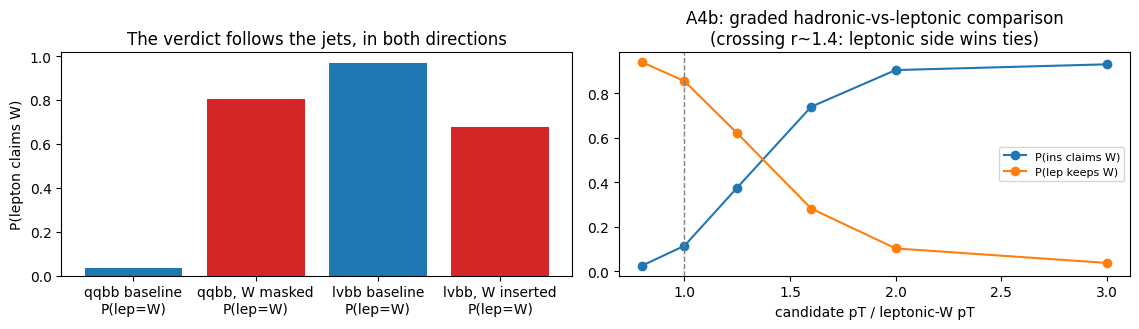

In [3]:
# direction 1: boosted qqbb, mask the W  (ran above: flip_lep)
# direction 2: lvbb with a free slot, insert a real donor W-ljet
lsel = torch.where(lvbb & ((T == PAD).sum(1) >= 1))[0]
slot_l = (T[lsel] == PAD).float().argmax(1)
rng = np.random.default_rng(0)
don = rng.integers(len(bsel_all), size=len(lsel))
Xi = X.clone(); Ti = T.clone()
lar = torch.arange(len(lsel))
donor_rows = X[bsel_all[don], wp_all[don]].clone(); donor_rows[:, 5:] = 0.0
Xi[lsel.unsqueeze(1), slot_l.unsqueeze(1)] = donor_rows.unsqueeze(1)
Ti[lsel, slot_l] = LJ
outi = fwd(Xi, Ti); pri = outi.argmax(-1)
ins_W = pri[lsel, slot_l] == W
lep_was_W = (pr0[lsel, lpos[lsel]] == W)
lep_now_W = pri[lsel, lpos[lsel]] == W
lep_drops = ((~lep_now_W) & lep_was_W).float().sum() / lep_was_W.float().sum()
print(f"lvbb + inserted real W-ljet: P(ins claims W) = {ins_W.float().mean():.3f}, "
      f"P(lep drops its W | had it) = {lep_drops:.3f}")
print(f"  coupling: P(lep=W | ins claims) = {lep_now_W[ins_W].float().mean():.3f}  "
      f"vs P(lep=W | no claim) = {lep_now_W[~ins_W].float().mean():.3f}"
      "   <- the broadcast is tight; the ~0.3 average is donor composition")

# the cross-system dose-response (A4b): candidate pT = r x pT(leptonic W)
lar = torch.arange(len(lsel))
pvec = X[lsel][lar, lpos[lsel], :2] + X[lsel][lar, npos[lsel], :2]
pt_lepW = torch.sqrt((pvec ** 2).sum(-1)).clamp(min=0.01)        # units of 100 GeV
RS_X = [0.8, 1.0, 1.25, 1.6, 2.0, 3.0]
dose_ins, dose_lep = [], []
for r in RS_X:
    X2 = X[lsel].clone(); T2 = T[lsel].clone()
    rows = torch.zeros(len(lsel), 7)
    p3, E = set_kin(donor_rows[:, :3], r * pt_lepW * 100, 80)
    rows[:, :3] = p3; rows[:, 3] = E; rows[:, 4] = WTAG
    X2[lar, slot_l] = rows; T2[lar, slot_l] = LJ
    pr = fwd(X2, T2).argmax(-1)
    dose_ins.append((pr[lar, slot_l] == W).float().mean().item())
    dose_lep.append((pr[lar, lpos[lsel]] == W).float().mean().item())

fig, (ax, axd) = plt.subplots(1, 2, figsize=(11.5, 3.4))
bars = [("qqbb baseline\nP(lep=W)", (pr0[bsel_all, lpos[bsel_all]] == W).float().mean()),
        ("qqbb, W masked\nP(lep=W)", (prm[bsel_all, lpos[bsel_all]] == W).float().mean()),
        ("lvbb baseline\nP(lep=W)", lep_was_W.float().mean()),
        ("lvbb, W inserted\nP(lep=W)", lep_now_W.float().mean())]
ax.bar([b[0] for b in bars], [b[1] for b in bars],
       color=["tab:blue", "tab:red", "tab:blue", "tab:red"])
ax.set_ylabel("P(lepton claims W)"); ax.set_title("The verdict follows the jets, in both directions")
axd.plot(RS_X, dose_ins, "o-", label="P(ins claims W)")
axd.plot(RS_X, dose_lep, "o-", label="P(lep keeps W)")
axd.axvline(1.0, ls="--", c="gray", lw=1)
axd.set_xlabel("candidate pT / leptonic-W pT")
axd.set_title("A4b: graded hadronic-vs-leptonic comparison\n(crossing r~1.4: leptonic side wins ties)")
axd.legend(fontsize=8)
plt.tight_layout(); os.makedirs(os.path.join(REPO, "tmp_plots"), exist_ok=True)
plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_ask_the_jets.png"), dpi=120)
plt.show()

---
## Claim 3 — W-candidacy is computed per-jet as relative-hardness x m2-window x
## anti-tag, and it is *contextual all the way down*

**Claim.** A jet's W-candidacy score rises with its hardness *relative to the
event* (NOT absolute pT), is shaped by an m2-window around the W mass (the model
sees m2, not m), and is suppressed by an H-like (Xbb) tag. There is no
context-free candidacy: cut a jet's context reads entirely and it cannot claim
at all (SB4).

**Evidence.** (i) Mass dose-response on the true W (A1): claim rate peaks near
80 GeV on the thesis model (live below). (ii) pT dose: softening the W kills its
claim (A1-pT); error autopsy: real misses are soft W-jets (B3).
(iii) **Relative not absolute** (RT4, causal): scale everything EXCEPT the W x2
and its claim rate falls 0.92->0.57 even though the W itself is untouched; scale
the WHOLE event x0.5 and claims survive. (iv) Tag surgery: a full H-disguise
(tag -> H-like) re-labels a true W as H (`wave3_tag_occlusion.py`).
(v) Candidacy is linearly decodable already at the embedding (AUC 0.93, D6) —
the single-object part is simple; the contextual part develops in blocks 0-1.

**Caveats / open**: the E2 occlusion *ranking* (pT >> mass ~ tag) conflated
perturbation sizes (red-team); the exact formula is NOT extracted yet (E4 PySR,
planned, with event-context features). The thesis model also penalises H-ward
masses so hard that mass can dominate pT in head-to-heads (RT3) — "the feature
ranking" is model-specific (see Claim 6).

**Causal? Yes** for relative-hardness, mass-window and tag (each via surgery).
**Confidence: high** for the feature set, **medium** for any specific functional
form (none extracted yet).

Live demo: A1 mass dose-response + the RT4 relative-hardness arms.

boosted with >=2 free slots: n=3085


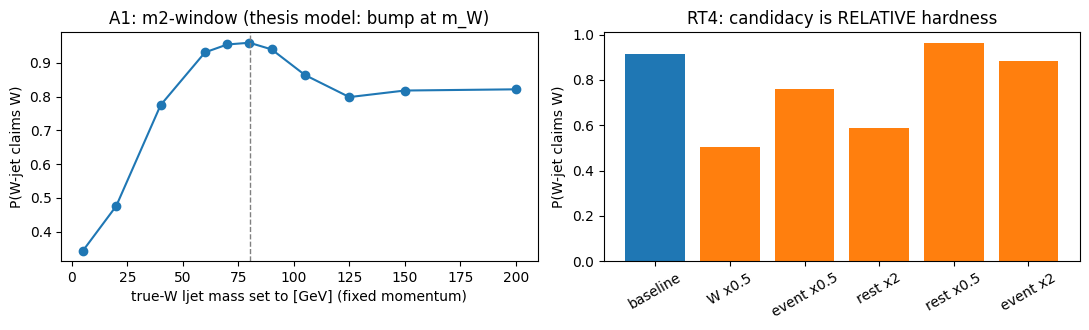

note: 'event x0.5' barely moves; 'rest x2' (W untouched!) suppresses -> the score is relative to event context.


In [4]:
bsel = torch.where(boosted & ((T == PAD).sum(1) >= 2))[0]   # >=2 slots reused later
NB = len(bsel)
wp = ((T[bsel] == LJ) & (TRU[bsel] == 2)).float().argmax(1)
bar2 = torch.arange(NB)
real = T[bsel] != PAD
m2_all = torch.clamp(X[bsel][..., 3] ** 2 - (X[bsel][..., :3] ** 2).sum(-1), min=0)
print(f"boosted with >=2 free slots: n={NB}")

masses = [5, 20, 40, 60, 70, 80, 90, 105, 125, 150, 200]
rates = []
for m in masses:
    X2 = X[bsel].clone()
    X2[bar2, wp, 3] = torch.sqrt((X2[bar2, wp, :3] ** 2).sum(-1) + (m / 100.0) ** 2)
    pr = fwd(X2, T[bsel]).argmax(-1)
    rates.append((pr[bar2, wp] == W).float().mean().item())

def scale_rest(scale_w, scale_rest_):
    X2 = X[bsel].clone()
    sc = torch.full(X2.shape[:2], 1.0); sc[real] = scale_rest_; sc[bar2, wp] = scale_w
    X2[..., :3] = X2[..., :3] * sc.unsqueeze(-1)
    X2[..., 3] = torch.sqrt((X2[..., :3] ** 2).sum(-1) + m2_all)
    X2[~real] = X[bsel][~real]
    return X2

arms = [("baseline", 1.0, 1.0), ("W x0.5", 0.5, 1.0), ("event x0.5", 0.5, 0.5),
        ("rest x2", 1.0, 2.0), ("rest x0.5", 1.0, 0.5), ("event x2", 2.0, 2.0)]
arm_rates = []
for nm, sw, sr in arms:
    pr = fwd(scale_rest(sw, sr), T[bsel]).argmax(-1)
    arm_rates.append((pr[bar2, wp] == W).float().mean().item())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(masses, rates, "o-"); a1.axvline(80.4, ls="--", c="gray", lw=1)
a1.set_xlabel("true-W ljet mass set to [GeV] (fixed momentum)")
a1.set_ylabel("P(W-jet claims W)"); a1.set_title("A1: m2-window (thesis model: bump at m_W)")
a2.bar([a[0] for a in arms], arm_rates, color=["tab:blue"] + ["tab:orange"] * 5)
a2.set_ylabel("P(W-jet claims W)"); a2.set_title("RT4: candidacy is RELATIVE hardness")
a2.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_candidacy.png"), dpi=120)
plt.show()
print("note: 'event x0.5' barely moves; 'rest x2' (W untouched!) suppresses ->"
      " the score is relative to event context.")

---
## Claim 4 — The verdict reaches lep & nu through two bottleneck scalars
## (b2h2 + b1h3), with a small secondary path (b2h0+b2h3); the set is closed

**Claim.** Of the 12 per-head bottleneck scalars entering the nu position, two
carry the verdict: **b2h2** ("W found"; sign-coded; in boosted events a
single-sender wire from the W-jet) and **b1h3** (hadronic-vs-leptonic
comparator). Overwriting both at nu flips its verdict in ~99.9% of events with
the lepton untouched. They carry ~80-90% of the causal flow; b2h0+b2h3 carry a
real ~12% secondary path; clamping all 12 reproduces the verdict EXACTLY (the
scalars are architecturally the only attention path in).

**Evidence & controls** (`wave2_wires.py`, `redteam_rt1/rt2/rt2b`): scalar census
(AUC vs prediction: b2h2 0.996, b1h3 0.989, replicated out-of-sample); D4-lite
overwrite 99.8-99.9% flips; **own-class placebo 0%**, **norm-matched random kick
2.1%**, non-wire scalar swaps tiny; input-side flip with wires clamped to clean
values -> restoration 81.6-90.7% (the "~95% fully determined" red-team
correction); clamping all 12 -> exactly 0 residual flips.

**Alternatives ruled out**: "any large perturbation flips it" (norm-matched kick
control), "the wires are epiphenomenal" (clamp blocks input-side flips), "more
wires hide elsewhere" (closure: all-12 clamp is exact).

**Causal? Yes**, with quantified completeness. **Confidence: very high** for the
wires' identity & role; the 80/90-vs-12 split is point-estimated on one slice.

Live demo: the two wires' scalars at the nu position, colored by true channel.

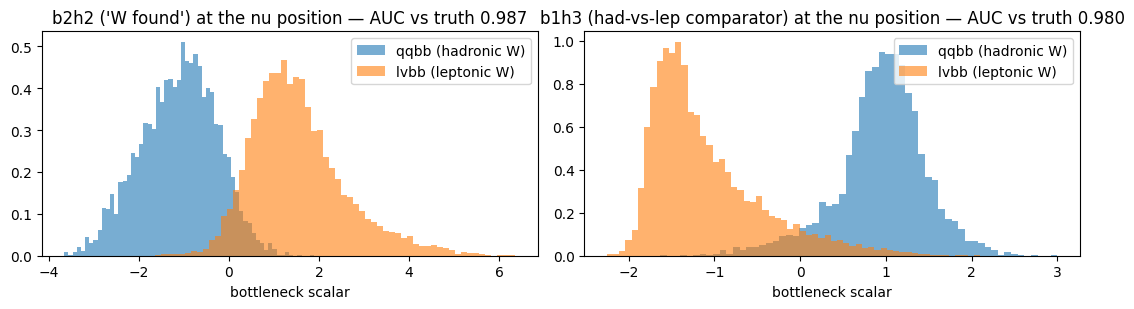

In [5]:
sc_b1, sc_b2 = [], []
with torch.no_grad():
    for c in range(0, N, 2048):
        sl = slice(c, min(c + 2048, N))
        model(X[sl][..., :5], T[sl])
        car = torch.arange(sl.stop - sl.start)
        sc_b1.append(cache.store["block_1_attention"]["bottleneck_activation"][car, 3, npos[sl], 0])
        sc_b2.append(cache.store["block_2_attention"]["bottleneck_activation"][car, 2, npos[sl], 0])
s_b1h3 = torch.cat(sc_b1).numpy(); s_b2h2 = torch.cat(sc_b2).numpy()
y = lvbb.numpy()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
for a, s, nm in ((a1, s_b2h2, "b2h2 ('W found')"), (a2, s_b1h3, "b1h3 (had-vs-lep comparator)")):
    a.hist(s[~y], bins=60, alpha=0.6, label="qqbb (hadronic W)", density=True)
    a.hist(s[y], bins=60, alpha=0.6, label="lvbb (leptonic W)", density=True)
    auc = roc_auc_score(y, s); auc = max(auc, 1 - auc)
    a.set_title(f"{nm} at the nu position — AUC vs truth {auc:.3f}")
    a.legend(); a.set_xlabel("bottleneck scalar")
plt.tight_layout(); plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_wires.png"), dpi=120)
plt.show()

---
## Claim 5 — "Competition" between W-candidates is per-jet context-relative
## scoring; the comparator is b2h2 itself; there is no inhibition edge

**Claim** (Stage B, resolved 2026-06-11). Two-candidate exclusivity is emergent
score-ranking, not a mechanism: at an exact tie BOTH claim in ~74% of events.
The circuit is two-stage and each stage is causally necessary: (1) blocks 0-1 —
each jet silently absorbs event context (including its rival); (2) block 2 —
**b2h2 alone** reads the rival and flips the marginally-weaker candidate. Each
jet suppresses only ITSELF via its own read: there is no winner->loser path.
The comparator resolves ~10-15% pT gaps (half-suppression), and an in-event
candidate enjoys a ~7%-pT-equivalent coherence advantage over a foreign insert.
The winner also pays (-3.3 margin vs its solo twin) — claim rates hid that.

**Evidence** (`stageb_sb{1,2,3,4}_*.py`, log `2026-06-11_stage-b-competition.md`):
- SB3: only block 2 has a jet<->jet attention asymmetry (loser->winner), and the
  top heads are IDENTICAL to the solo rest-x2 mediation set (shared machinery).
- SB2: big gaps resolve at blk0-1; near-ties flip AT block 2.
- SB4 (surgical edge knockout, validated to 0 dev vs the library hook):
  b2h2-only KO restores the tie loser 93%; h0/h3 do nothing (despite b2h3 having
  the LARGEST attention — attention mass != causal weight). Direction-resolved KO
  shows self-suppression only. The b0+b1 "expected-null control" ALSO restores ->
  two-stage structure. Solo KO: no context => no candidacy at all (and the lepton
  coherently takes the W).
- SB1: symmetrized design crosses at r=1.00 exactly; the asym design at r~1.07.

**Alternatives ruled out**: B-iii independent thresholds (tie -> both claim 74%,
far above independence); B-i strong mutual inhibition (same tie result); B-i weak
directed suppression edge (direction-resolved KO: cutting the winner's read of
the loser changes only the WINNER's claim).

**Causal? Yes** (edge-level knockouts with validation + controls).
**Confidence: high** on this model/slice; the knockout state is off-manifold by
construction (renorm + no-renorm agree, which mitigates); organism universality
not yet run (Claim 6 says: do not assume it).

Live demos: (a) SB1 dose-response curves; (b) tie-cell lens timing; (c) the
decisive knockout.

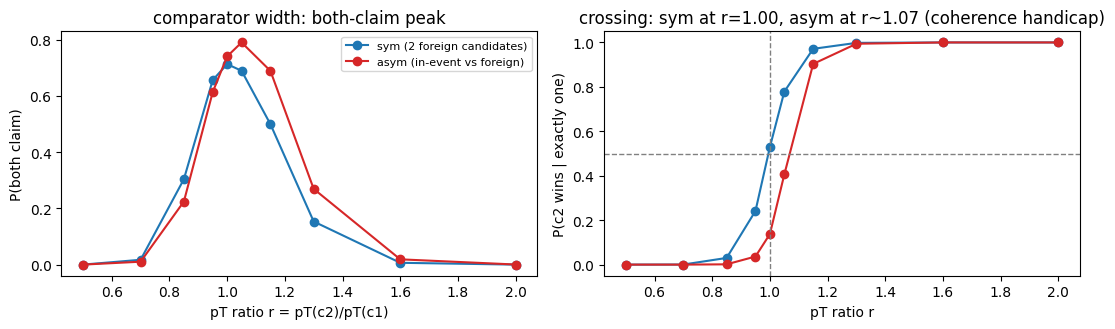

In [6]:
# (a) SB1 dose-response (lighter grid than the script)
pads = (T[bsel] == PAD).float()
slot1 = pads.argmax(1)
pads2 = pads.clone(); pads2[bar2, slot1] = 0
slot2 = pads2.argmax(1)
dd1 = X[bsel[rng.integers(NB, size=NB)], wp[rng.integers(NB, size=NB)], :3].clone()
dd2 = X[bsel[rng.integers(NB, size=NB)], wp[rng.integers(NB, size=NB)], :3].clone()

def insert(X2, T2, pos, direction, pt, m):
    rows = torch.zeros(NB, 7)
    p3, E = set_kin(direction, pt, m)
    rows[:, :3] = p3; rows[:, 3] = E; rows[:, 4] = WTAG
    X2[bar2, pos] = rows; T2[bar2, pos] = LJ

def run_design(r, sym):
    X2 = X[bsel].clone(); T2 = T[bsel].clone()
    if sym:
        T2[bar2, wp] = PAD; X2[bar2, wp] = 0.0
        insert(X2, T2, slot1, dd1, 600, 80); insert(X2, T2, slot2, dd2, 600 * r, 80)
        p1, p2 = slot1, slot2
    else:
        p3, E = set_kin(X2[bar2, wp, :3], 600, 80)
        X2[bar2, wp, :3] = p3; X2[bar2, wp, 3] = E; X2[bar2, wp, 4] = WTAG
        insert(X2, T2, slot1, dd1, 600 * r, 80)
        p1, p2 = wp, slot1
    pr = fwd(X2, T2).argmax(-1)
    c1 = pr[bar2, p1] == W; c2 = pr[bar2, p2] == W
    one = c1 ^ c2
    return (c1 & c2).float().mean().item(), \
           (c2[one]).float().mean().item() if one.sum() else np.nan

RS = [0.5, 0.7, 0.85, 0.95, 1.0, 1.05, 1.15, 1.3, 1.6, 2.0]
res = {True: [], False: []}
for sym in (False, True):
    for r in RS:
        res[sym].append(run_design(r, sym))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
for sym, nm, c in ((True, "sym (2 foreign candidates)", "tab:blue"),
                   (False, "asym (in-event vs foreign)", "tab:red")):
    a1.plot(RS, [v[0] for v in res[sym]], "o-", color=c, label=nm)
    a2.plot(RS, [v[1] for v in res[sym]], "o-", color=c, label=nm)
a1.set_xlabel("pT ratio r = pT(c2)/pT(c1)"); a1.set_ylabel("P(both claim)")
a1.set_title("comparator width: both-claim peak"); a1.legend(fontsize=8)
a2.axhline(0.5, ls="--", c="gray", lw=1); a2.axvline(1.0, ls="--", c="gray", lw=1)
a2.set_xlabel("pT ratio r"); a2.set_ylabel("P(c2 wins | exactly one)")
a2.set_title("crossing: sym at r=1.00, asym at r~1.07 (coherence handicap)")
plt.tight_layout(); plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_sb1.png"), dpi=120)
plt.show()

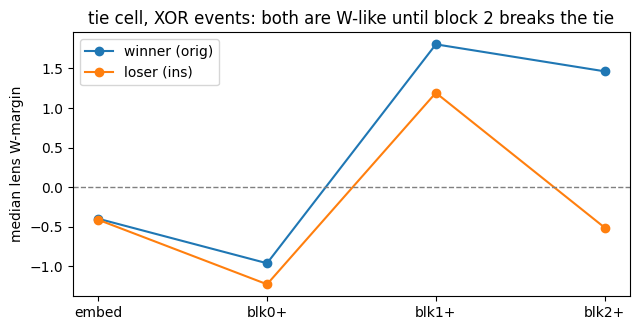

In [7]:
# (b) tie-cell lens timing (winner vs loser, XOR events) — exact lens (no LayerNorm)
STREAMS = {}
def make_pre(name):
    def fn(module, args, kwargs): STREAMS[name] = args[0].detach()
    return fn
pre_handles = [blk["self_attention"].register_forward_pre_hook(make_pre(f"d{i}"), with_kwargs=True)
               for i, blk in enumerate(model.attention_blocks)]
pre_handles.append(model.classifier.register_forward_pre_hook(make_pre(f"d{NBLK}"), with_kwargs=True))

X2 = X[bsel].clone(); T2 = T[bsel].clone()
p3, E = set_kin(X2[bar2, wp, :3], 600, 80)
X2[bar2, wp, :3] = p3; X2[bar2, wp, 3] = E; X2[bar2, wp, 4] = WTAG
insert(X2, T2, slot1, dd1, 600, 80)
mg_o = [[] for _ in range(NBLK + 1)]; mg_i = [[] for _ in range(NBLK + 1)]; prs = []
with torch.no_grad():
    for c in range(0, NB, 2048):
        sl = slice(c, min(c + 2048, NB))
        prs.append(model(X2[sl][..., :5], T2[sl]).argmax(-1))
        snap = {d: STREAMS[f"d{d}"] for d in range(NBLK + 1)}
        car = torch.arange(sl.stop - sl.start)
        for d in range(NBLK + 1):
            L = model.classifier(snap[d]); m = L[..., W] - L[..., 0]
            mg_o[d].append(m[car, wp[sl]]); mg_i[d].append(m[car, slot1[sl]])
pr = torch.cat(prs)
ow = pr[bar2, wp] == W; iw = pr[bar2, slot1] == W
o_only = ow & ~iw
mo = [torch.cat(v) for v in mg_o]; mi = [torch.cat(v) for v in mg_i]
depths = ["embed", "blk0+", "blk1+", "blk2+"][:NBLK + 1]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(depths, [m[o_only].median().item() for m in mo], "o-", label="winner (orig)")
ax.plot(depths, [m[o_only].median().item() for m in mi], "o-", label="loser (ins)")
ax.axhline(0, ls="--", c="gray", lw=1)
ax.set_ylabel("median lens W-margin"); ax.legend()
ax.set_title("tie cell, XOR events: both are W-like until block 2 breaks the tie")
plt.tight_layout(); plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_sb2.png"), dpi=120)
plt.show()
for h in pre_handles: h.remove()

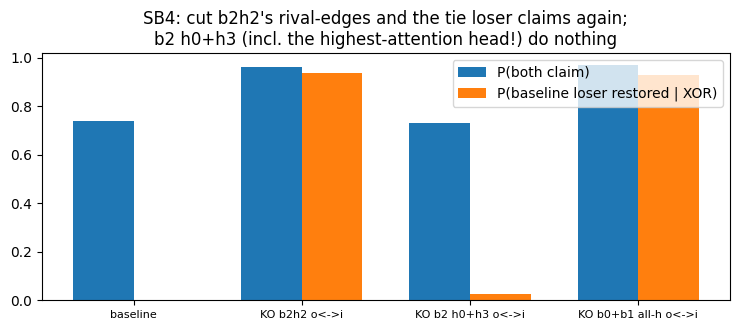

In [8]:
# (c) the decisive knockout — surgical attention recompute with edge KO
# (compact version of stageb_sb4_edge_knockout.py; validated there to 0 dev)
KO = {"active": False}
def make_surgical(block_idx, block):
    bdown, bup = block["bottleneck_down"], block["bottleneck_up"]
    def hook_fn(module, inputs, kwargs, output):
        q0 = inputs[0]
        kpm = kwargs.get("key_padding_mask", None)
        kpm = F._canonical_mask(mask=kpm, mask_name="key_padding_mask",
                                other_type=F._none_or_dtype(kpm), other_name="",
                                target_type=q0.dtype)
        q = k = v = q0.transpose(1, 0)
        tgt, bsz, E_ = q.shape
        q, k, v = F._in_projection_packed(q, k, v, module.in_proj_weight, module.in_proj_bias)
        hd = E_ // NH
        q = q.view(tgt, bsz * NH, hd).transpose(0, 1)
        k = k.view(tgt, bsz * NH, hd).transpose(0, 1)
        v = v.view(tgt, bsz * NH, hd).transpose(0, 1)
        qs = q * math.sqrt(1.0 / float(hd))
        kpm_e = kpm.view(bsz, 1, 1, tgt).expand(-1, NH, -1, -1).reshape(bsz * NH, 1, tgt)
        A = torch.baddbmm(kpm_e, qs, k.transpose(-2, -1))
        A = F.softmax(A, dim=-1).view(bsz, NH, tgt, tgt)
        if KO["active"] and block_idx in KO["blocks"]:
            car = torch.arange(bsz)
            for g in range(KO["q"].shape[0]):
                for h in KO["heads"]:
                    row = A[car, h, KO["q"][g], :] * (~KO["kmask"][g]).float()
                    A[car, h, KO["q"][g], :] = row / row.sum(-1, keepdim=True).clamp(min=1e-9)
        ob = torch.bmm(A.view(bsz * NH, tgt, tgt), v).transpose(0, 1).contiguous().view(tgt * bsz, E_)
        per_head = torch.empty(bsz, NH, tgt, E_)
        for h in range(NH):
            Wr = module.out_proj.weight.transpose(0, 1)[h * hd:(h + 1) * hd]
            per_head[:, h] = torch.matmul(ob[:, h * hd:(h + 1) * hd], Wr).view(tgt, bsz, -1).transpose(0, 1)
        for h in range(NH):
            s = torch.matmul(per_head[:, h].reshape(-1, E_), bdown[h].weight.t())
            per_head[:, h] = torch.matmul(s, bup[h].weight.t()).view(bsz, tgt, E_)
        return per_head.sum(dim=1) + module.out_proj.bias, output[1]
    return hook_fn

for h in lib_handles: h.remove()          # avoid double hooks
sur_handles = [blk["self_attention"].register_forward_hook(make_surgical(i, blk), with_kwargs=True)
               for i, blk in enumerate(model.attention_blocks)]

def onehot(pos):
    m = torch.zeros(NB, 15, dtype=torch.bool); m[bar2, pos] = True; return m

def fwd_ko(x, types, blocks=None, heads=None, edges=None):
    outs = []
    with torch.no_grad():
        for c in range(0, len(x), 2048):
            sl = slice(c, min(c + 2048, len(x)))
            if blocks is None:
                KO["active"] = False
            else:
                KO.update(active=True, blocks=blocks, heads=heads,
                          q=torch.stack([g[0][sl] for g in edges]),
                          kmask=torch.stack([g[1][sl] for g in edges]))
            outs.append(model(x[sl][..., :5], types[sl]))
    KO["active"] = False
    return torch.cat(outs)

EB = [(wp, onehot(slot1)), (slot1, onehot(wp))]            # o<->i edges
conds = [("baseline", None, None),
         ("KO b2h2 o<->i", {2}, (2,)),
         ("KO b2 h0+h3 o<->i", {2}, (0, 3)),
         ("KO b0+b1 all-h o<->i", {0, 1}, tuple(range(NH)))]
out_b = fwd_ko(X2, T2)
prb = out_b.argmax(-1)
xor0 = (prb[bar2, wp] == W) ^ (prb[bar2, slot1] == W)
loser_pos = torch.where(prb[bar2, wp] == W, slot1, wp)
labels, both_r, rest_r = [], [], []
for nm, blocks, heads in conds:
    o = out_b if blocks is None else fwd_ko(X2, T2, blocks, heads, EB)
    p = o.argmax(-1)
    cw, ci = p[bar2, wp] == W, p[bar2, slot1] == W
    labels.append(nm); both_r.append((cw & ci).float().mean().item())
    rest_r.append((p[bar2, loser_pos] == W)[xor0].float().mean().item())
fig, ax = plt.subplots(figsize=(7.5, 3.4))
xpos = np.arange(len(labels))
ax.bar(xpos - 0.18, both_r, 0.36, label="P(both claim)")
ax.bar(xpos + 0.18, rest_r, 0.36, label="P(baseline loser restored | XOR)")
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=8)
ax.set_title("SB4: cut b2h2's rival-edges and the tie loser claims again;\n"
             "b2 h0+h3 (incl. the highest-attention head!) do nothing")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(REPO, "tmp_plots", "narrative_sb4.png"), dpi=120)
plt.show()
for h in sur_handles: h.remove()
lib_handles = [m.register_forward_hook(fn, with_kwargs=True)
               for m, fn in hook_attention_heads(model, cache, detach=True,
                     SINGLE_ATTENTION=False, bottleneck_attention_output=1)]

---
## Claim 6 — Findings do NOT automatically transfer across model scale

**Claim.** The 20k-param organism (`ent1-d20-2blk`) solves the same task with the
same coarse structure (ask-the-jets, parallel broadcast, relative hardness) but
DIFFERENT feature weighting: its A1 mass dose-response is monotonic (no m_W
bump), and it ranks candidates pT-first everywhere, while the thesis model
penalises H-ward masses so heavily that (pT450,m80) beats (pT600,m110) ~90/10.

**Evidence**: A1 on both models + both organisms (`plot_a1_mass_dose.py`); RT3
factorial cells per model; RT4 relative-hardness replicates on BOTH (the
*contextual* property is shared; the *features* differ).

**Implication**: universality is a per-finding empirical question. Run every
Stage-B claim on the organism before believing it generalizes (queued).
**Confidence: high** (replicated), but n_models = 2.

---
## Scoreboard

| claim | causal? | controls | replicated out-of-sample? | confidence |
|---|---|---|---|---|
| 1. lockstep = shared wiring | yes (bidirectional overwrite) | placebo 0%, random kick 2% | yes (RT1) | very high |
| 2. verdict = graded hadronic-vs-leptonic comparison ("weigh the jets") | yes (input surgery both ways, dose-controlled) | sham masks, mediation, donor-composition strat, direction control | yes (+organism) | very high |
| 3. candidacy features (rel-hardness, m2-win, tag) | yes per-feature | physically-consistent surgery | yes (RT4/RT6) | high (formula NOT extracted) |
| 4. wires b2h2+b1h3 (+12% b2h0/h3), closed set | yes (overwrite/clamp/closure) | placebo, norm-matched kick, non-wire swaps | yes (RT1) | very high |
| 5. competition = context scoring via b2h2; no inhibition edge | yes (validated edge KO) | direction-resolved, per-head, no-renorm, b0/b1 | fresh slice (single session) | high |
| 6. cross-scale divergence | observational + factorial | — | both organisms | high (n=2 models) |

**What is NOT established yet**: the closed-form candidacy score (E4 PySR
planned); Stage-B universality on the organism; when the comparator forms during
training (F1); the resolved-channel (2-sjet) story beyond "detection weak +
unspecific"; the H-side competition; faithfulness-by-replacement (the Phase-3
punchline experiment).

**Where everything lives**: preregs+results `docs/H1_ASK_THE_JETS_TEST_PLAN.md`;
chronology `docs/logs/2026-06-10_planning-and-data-recovery.md` (rounds/waves),
`2026-06-11_red-team-h1.md`, `2026-06-11_stage-b-competition.md`; scripts
`experiments/h1/` (inventory in `experiments/README.md`).

In [9]:
print("narrative complete — plots in tmp_plots/narrative_*.png")

narrative complete — plots in tmp_plots/narrative_*.png
